# Lab Assignment 4: Support Vector Machines

In this exercise, we return to the wine quality dataset. However, this time, we will attempt to separate various pieces of cloathing using a Support Vector Machine (SVM). Below, we gather the data and preprocess it for you. As your task, you need to implement an SVM solver, perform finetuning and classification, and finally, show your results using a confusion matrix.

## Library installation
In this lab we will use the `cvxopt` package, [whose documentation can be found here](https://cvxopt.org/userguide/index.html).

We are running version 1.3.2 of `cvxopt`.

In [4]:
!pip install cvxopt
!pip install scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ----------- ---------------------------- 2.4/8.1 MB 15.0 MB/s eta 0:00:01
   ------------------------------------ --- 7.3/8.1 MB 19.8 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 19.2 MB/s  0:00:00

   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [sc


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Package Imports

In [5]:
## =======================================================
## Import Key Packages
## =======================================================
## Standard Fare
import numpy as np
from scipy.io import loadmat

## CVX Opt
import cvxopt
from cvxopt import solvers
from cvxopt import matrix
from sklearn.model_selection import train_test_split
import pandas as pd

solvers.options['show_progress'] = False

## Accessing the Data

In [6]:
training_data = pd.read_csv('./fashion-mnist_train.csv')

y = training_data['label']
X = training_data.drop('label',axis=1)

X = X[:2000]
X = X.astype(float) / 255.0
y = y[:2000]

train_samples, test_samples, train_samples_labels, test_samples_labels = train_test_split(X, y, test_size=0.1, random_state=42, shuffle=True)

test_samples_labels=np.squeeze(test_samples_labels)
train_samples_labels=np.squeeze(train_samples_labels)

In [7]:
label_to_title = {0: 'T-shirt/top', 
                  1:'Trouser', 
                  2:'Pullover', 
                  3:'Dress', 
                  4:'Coat', 
                  5:'Sandal',
                  6:'Shirt', 
                  7:'Sneaker', 
                  8:'Bag',
                  9:'Ankle boot'}

In [8]:
print(np.unique(train_samples_labels))
print(np.unique(test_samples_labels))

for i in np.unique(train_samples_labels):
    print(f' There are {sum(train_samples_labels==i)} instances of label #{i}:{label_to_title[i]} in the Train dataset')

[0 1 2 3 4 5 6 7 8 9]
[0 1 2 3 4 5 6 7 8 9]
 There are 197 instances of label #0:T-shirt/top in the Train dataset
 There are 182 instances of label #1:Trouser in the Train dataset
 There are 187 instances of label #2:Pullover in the Train dataset
 There are 190 instances of label #3:Dress in the Train dataset
 There are 200 instances of label #4:Coat in the Train dataset
 There are 160 instances of label #5:Sandal in the Train dataset
 There are 188 instances of label #6:Shirt in the Train dataset
 There are 165 instances of label #7:Sneaker in the Train dataset
 There are 168 instances of label #8:Bag in the Train dataset
 There are 163 instances of label #9:Ankle boot in the Train dataset


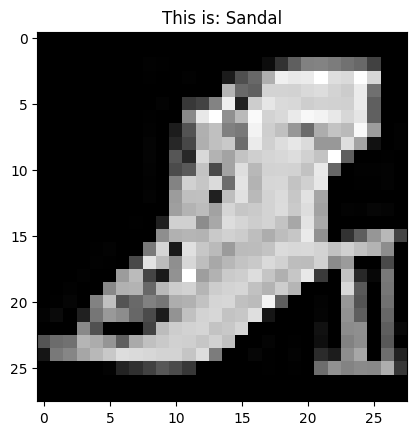

In [9]:
import matplotlib.pyplot as plt
import random

ind = random.randint(0,2000)
plt.imshow(X[ind:ind+1].values.reshape(28,28),cmap='gray')
plt.title(f'This is: {label_to_title[y[ind:ind+1].values[0]]}')
plt.show()

## Task 1:
Develop code for training an SVM for binary classification with nonlinear kernels. You'll need to accomodate non-overlapping class distributions. One way to implement this is to maximize (7.32) subject to (7.33) and (7.34) [in Bishop](https://www.microsoft.com/en-us/research/uploads/prod/2006/01/Bishop-Pattern-Recognition-and-Machine-Learning-2006.pdf). It may be helpful to redefine these as matrix operations. Let ${1}\in\mathbb{R}^{N\times 1}$ be the vector whose entries are all 1's. Let $\mathbf{a}\in\mathbb{R}^{N\times 1}$ have entries $a_i$. Let $\mathbf{T}\in\mathbb{R}^{N\times N}$ be a diagonal matrix with $\mathbf{T}_{ii} = t_i$ on the diagonal. Then we can reformulate the objective to be

\begin{equation*}
\begin{aligned}
& \text{maximize}
& & \tilde{L}(\mathbf{a}) = {1}^{\mathrm{T}}\mathbf{a} - \frac{1}{2} \mathbf{a}^{\mathrm{T}} \mathbf{T}\mathbf{K} \mathbf{T}\mathbf{a} \\
& \text{subject to}
& & {1}^{\mathrm{T}} \mathbf{a} \preceq C \\
& & & {1}^{\mathrm{T}} \mathbf{a} \succeq 0 \\
& & & \mathbf{a}^{\mathrm{T}} \mathbf{t} = 0
\end{aligned}
\end{equation*}

The "$\preceq$" symbol here means element-wise comparison. This formulation is very close to what `cvxopt` expects.

Hint (`cvxopt` expects the following form):

\begin{equation*}
\begin{aligned}
& \text{minimize}
& & \tilde{L}(\mathbf{a}) = \frac{1}{2} \mathbf{a}^{\mathrm{T}} \mathbf{T}\mathbf{K} \mathbf{T}\mathbf{a} - {1}^{\mathrm{T}}\mathbf{a} \\
& \text{subject to}
& & G \mathbf{a} \preceq h \\
& & & {\mathbf{t}}^{\mathrm{T}}\mathbf{a} = 0
\end{aligned}
\end{equation*}

where $G$ is an $N\times N$ identity matrix ontop of $-1$ times an $N\times N$ identity matrix and $h \in\mathbb{R}^{2N}$ where the first $N$ entries are $C$ and the second $N$ enties are $0$.

## Task 2:
Develop code to predict the $\{-1,+1\}$ class for new data. To use the predictive model (7.13) you need to determine $b$, which can be done with (7.37). 

We have provided some starter code in the cells below

In [10]:
def nonlinear_kernel(X, Y, kernel='rbf', gamma=None, degree=3, coef0=1.0):
  X = np.asarray(X, dtype=float)
  Y = np.asarray(Y, dtype=float)
  if gamma is None:
    gamma = 1.0 / X.shape[1]
  dot = X @ Y.T
  if kernel == 'linear':
    return dot
  if kernel == 'poly':
    return (gamma * dot + coef0) ** degree
  if kernel == 'sigmoid':
    return np.tanh(gamma * dot + coef0)
  X_sq = np.einsum('ij,ij->i', X, X)
  Y_sq = np.einsum('ij,ij->i', Y, Y)
  sq_dists = X_sq[:, None] + Y_sq[None, :] - 2.0 * dot
  np.clip(sq_dists, 0.0, None, out=sq_dists)
  return np.exp(-gamma * sq_dists)

In [11]:
class SVM:

  def __init__(self, kernel=nonlinear_kernel, C=1.0):
    self.kernel = kernel
    self.C = C

  def fit(self, X, y):
    X = np.asarray(X, dtype=float)
    t = np.where(np.asarray(y) > 0, 1.0, -1.0)
    n = len(t)
    K = self.kernel(X, X)
    P = matrix((np.outer(t, t) * K + 1e-8 * np.eye(n)).astype(float))
    q = matrix(-np.ones(n))
    G = matrix(np.vstack([-np.eye(n), np.eye(n)]))
    h = matrix(np.concatenate([np.zeros(n), np.full(n, self.C)]))
    A = matrix(t[None, :])
    b_eq = matrix(0.0)
    sol = solvers.qp(P, q, G, h, A, b_eq)
    alphas = np.asarray(sol['x']).ravel()
    sv = alphas > 1e-5
    self._sv_X = X[sv]
    self._sv_t = t[sv]
    self._sv_a = alphas[sv]
    on_margin = (self._sv_a > 1e-5) & (self._sv_a < self.C - 1e-5)
    if not on_margin.any():
      on_margin = np.ones(len(self._sv_a), dtype=bool)
    K_mv = self.kernel(self._sv_X[on_margin], self._sv_X)
    weighted_sum = K_mv @ (self._sv_a * self._sv_t)
    self.bias = float(np.mean(self._sv_t[on_margin] - weighted_sum))
    return self

  def decision_function(self, X):
    K = self.kernel(np.asarray(X, dtype=float), self._sv_X)
    return K @ (self._sv_a * self._sv_t) + self.bias

  def predict(self, X):
    return np.sign(self.decision_function(X)).astype(int)

  def score(self, X, y):
    t_true = np.where(np.asarray(y) > 0, 1, -1)
    return float(np.mean(self.predict(X) == t_true))

## Task 3:
Using your implementation, compare multiclass classification performance of two different voting schemes:
* one vs. rest
* one vs. one

In [12]:
X_train = train_samples.values
y_train = train_samples_labels.values
X_test  = test_samples.values
y_test  = test_samples_labels.values
classes = np.unique(y_train)

def make_rbf(gamma):
  return lambda A, B: nonlinear_kernel(A, B, kernel='rbf', gamma=gamma)

def fit_ovr(X, y, classes, C, gamma):
  kfn = make_rbf(gamma)
  return {cls: SVM(kernel=kfn, C=C).fit(X, np.where(y == cls, 1, -1)) for cls in classes}

def predict_ovr(models, X):
  cls_list = list(models.keys())
  scores = np.column_stack([models[c].decision_function(X) for c in cls_list])
  return np.array(cls_list)[np.argmax(scores, axis=1)]

def fit_ovo(X, y, classes, C, gamma):
  kfn = make_rbf(gamma)
  models = []
  for i, c1 in enumerate(classes):
    for c2 in classes[i + 1:]:
      mask = (y == c1) | (y == c2)
      models.append((c1, c2, SVM(kernel=kfn, C=C).fit(X[mask], np.where(y[mask] == c1, 1, -1))))
  return models

def predict_ovo(models, X, classes):
  idx = {c: i for i, c in enumerate(classes)}
  vote_counts = np.zeros((len(X), len(classes)))
  vote_scores = np.zeros((len(X), len(classes)))
  for c1, c2, svm in models:
    s = svm.decision_function(X)
    vote_counts[:, idx[c1]] += (s > 0)
    vote_counts[:, idx[c2]] += (s < 0)
    vote_scores[:, idx[c1]] += np.maximum(s, 0)
    vote_scores[:, idx[c2]] += np.maximum(-s, 0)
  max_votes = vote_counts.max(axis=1, keepdims=True)
  tiebreaker = np.where(vote_counts == max_votes, vote_scores, -np.inf)
  return np.array(classes)[np.argmax(tiebreaker, axis=1)]

In [ ]:
C_init = 5.0
gamma_init = 1e-3

print('Training One-vs-Rest...')
ovr_models = fit_ovr(X_train, y_train, classes, C=C_init, gamma=gamma_init)
ovr_preds  = predict_ovr(ovr_models, X_test)
print(f'OvR accuracy (C={C_init}, gamma={gamma_init}): {np.mean(ovr_preds == y_test):.3f}')

print('Training One-vs-One...')
ovo_models = fit_ovo(X_train, y_train, classes, C=C_init, gamma=gamma_init)
ovo_preds  = predict_ovo(ovo_models, X_test, classes)
print(f'OvO accuracy (C={C_init}, gamma={gamma_init}): {np.mean(ovo_preds == y_test):.3f}')

## Task 4:
The parameter $C>0$ controls the tradeoff between the size of the margin and the slack variable penalty. It is analogous to the inverse of a regularization coefficient. Include in your report a brief discussion of how you found an appropriate value.

Hint: Try using np.linspace or logspace for hyperparameter tuning

Hint: I recommend **high** C 

In [ ]:
N_sub = 800
N_val = 200
X_sub = X_train[:N_sub]
y_sub = y_train[:N_sub]
X_val = X_train[N_sub:N_sub + N_val]
y_val = y_train[N_sub:N_sub + N_val]

C_grid     = np.logspace(-1, 1, 5)
gamma_grid = np.logspace(-4, -2, 6)

best_acc, best_C, best_gamma = -1.0, None, None

for C in C_grid:
  for g in gamma_grid:
    preds = predict_ovr(fit_ovr(X_sub, y_sub, classes, C=C, gamma=g), X_val)
    acc   = np.mean(preds == y_val)
    print(f'C={C:.3f}  gamma={g:.1e}  val_acc={acc:.3f}')
    if acc > best_acc:
      best_acc, best_C, best_gamma = acc, float(C), float(g)

print(f'Best: C={best_C}, gamma={best_gamma:.1e}, val_acc={best_acc:.3f}')

## Task 5:
In addition to calculating percent accuracy, generate multiclass [confusion matrices](https://en.wikipedia.org/wiki/confusion_matrix) as part of your analysis.

In [ ]:
final_models = fit_ovr(X_train, y_train, classes, C=best_C, gamma=best_gamma)
predictions  = predict_ovr(final_models, X_test)
print(f'Final test accuracy (C={best_C}, gamma={best_gamma:.1e}): {np.mean(predictions == y_test):.3f}')

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, predictions, labels=classes)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
class_names = [label_to_title[c] for c in classes]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=axes[0], colorbar=False, xticks_rotation='vertical')
axes[0].set_title('Counts')
ConfusionMatrixDisplay(cm_norm, display_labels=class_names).plot(ax=axes[1], colorbar=False, xticks_rotation='vertical')
axes[1].set_title('Row-Normalized Recall')
plt.tight_layout()
plt.show()

print('Per-class recall:')
for i, cls in enumerate(classes):
  print(f'  {label_to_title[cls]:15s}: {cm_norm[i, i]:.2f}')

### What to Submit
Please submit the following:

1. A Jupyter noteboon that contains your completed notebook, where the output of each cell is clearly displayed.

2. A brief write-up that answers the 5 questions posed in this lab and justifies your model. Ensure that any figures you create are accessible and easy to understand.

In [13]:
# ------------------------------------------------------------------ #
# Sanity checks - runs in seconds on tiny synthetic data
# ------------------------------------------------------------------ #
import traceback

passed = 0
failed = 0

def check(name, condition):
  global passed, failed
  if condition:
    print(f'  PASS  {name}')
    passed += 1
  else:
    print(f'  FAIL  {name}')
    failed += 1

def run(name, fn):
  global failed
  try:
    fn()
  except Exception:
    print(f'  ERROR {name}')
    traceback.print_exc()
    failed += 1

rng = np.random.default_rng(0)

# --- kernel tests ---
A = rng.standard_normal((4, 3))
B = rng.standard_normal((5, 3))

def test_kernel_shapes():
  for kname in ('rbf', 'poly', 'sigmoid', 'linear'):
    K = nonlinear_kernel(A, B, kernel=kname)
    check(f'kernel {kname} shape (4,5)', K.shape == (4, 5))

def test_rbf_diagonal_is_one():
  K = nonlinear_kernel(A, A, kernel='rbf')
  check('RBF diagonal == 1', np.allclose(np.diag(K), 1.0))

def test_rbf_symmetric():
  K = nonlinear_kernel(A, A, kernel='rbf')
  check('RBF symmetric', np.allclose(K, K.T))

def test_linear_matches_dot():
  K = nonlinear_kernel(A, B, kernel='linear')
  check('linear kernel == A @ B.T', np.allclose(K, A @ B.T))

run('kernel shapes',           test_kernel_shapes)
run('RBF diagonal == 1',       test_rbf_diagonal_is_one)
run('RBF symmetric',           test_rbf_symmetric)
run('linear kernel == A@B.T',  test_linear_matches_dot)

# --- SVM binary tests ---
# Two clearly separable clusters
X_pos = rng.standard_normal((20, 8)) + 3
X_neg = rng.standard_normal((20, 8)) - 3
X_bin = np.vstack([X_pos, X_neg])
y_bin = np.array([1]*20 + [-1]*20)

def test_svm_fit_returns_self():
  svm = SVM(C=1.0)
  ret = svm.fit(X_bin, y_bin)
  check('fit() returns self', ret is svm)

def test_svm_has_support_vectors():
  svm = SVM(C=1.0).fit(X_bin, y_bin)
  check('has support vectors', len(svm._sv_X) > 0)

def test_svm_predict_shape():
  svm = SVM(C=1.0).fit(X_bin, y_bin)
  preds = svm.predict(X_bin)
  check('predict shape matches input', preds.shape == (40,))

def test_svm_predict_values():
  svm = SVM(C=1.0).fit(X_bin, y_bin)
  preds = svm.predict(X_bin)
  check('predict returns only +1/-1', set(preds).issubset({1, -1}))

def test_svm_separable_accuracy():
  svm = SVM(C=1.0).fit(X_bin, y_bin)
  check('perfect accuracy on separable data', svm.score(X_bin, y_bin) == 1.0)

def test_decision_function_shape():
  svm = SVM(C=1.0).fit(X_bin, y_bin)
  df = svm.decision_function(X_bin)
  check('decision_function shape', df.shape == (40,))

def test_decision_function_sign_matches_predict():
  svm = SVM(C=1.0).fit(X_bin, y_bin)
  check('sign(decision_function) == predict',
        np.all(np.sign(svm.decision_function(X_bin)) == svm.predict(X_bin)))

run('fit returns self',                   test_svm_fit_returns_self)
run('has support vectors',                test_svm_has_support_vectors)
run('predict shape',                      test_svm_predict_shape)
run('predict values in {+1,-1}',          test_svm_predict_values)
run('perfect accuracy separable',         test_svm_separable_accuracy)
run('decision_function shape',            test_decision_function_shape)
run('sign(df) == predict',                test_decision_function_sign_matches_predict)

# --- multiclass tests ---
# 3-class toy problem, 10 samples each, well separated
X_mc = np.vstack([
  rng.standard_normal((10, 8)) + np.array([5, 0, 0, 0, 0, 0, 0, 0]),
  rng.standard_normal((10, 8)) + np.array([0, 5, 0, 0, 0, 0, 0, 0]),
  rng.standard_normal((10, 8)) + np.array([0, 0, 5, 0, 0, 0, 0, 0]),
])
y_mc = np.array([0]*10 + [1]*10 + [2]*10)
cls_mc = np.array([0, 1, 2])

def test_ovr_output_shape():
  m = fit_ovr(X_mc, y_mc, cls_mc, C=1.0, gamma=0.5)
  preds = predict_ovr(m, X_mc)
  check('OvR output shape', preds.shape == (30,))

def test_ovr_output_values():
  m = fit_ovr(X_mc, y_mc, cls_mc, C=1.0, gamma=0.5)
  preds = predict_ovr(m, X_mc)
  check('OvR values in class set', set(preds).issubset(set(cls_mc)))

def test_ovr_separable_accuracy():
  m = fit_ovr(X_mc, y_mc, cls_mc, C=1.0, gamma=0.5)
  preds = predict_ovr(m, X_mc)
  check('OvR perfect accuracy on separable', np.mean(preds == y_mc) == 1.0)

def test_ovo_output_shape():
  m = fit_ovo(X_mc, y_mc, cls_mc, C=1.0, gamma=0.5)
  preds = predict_ovo(m, X_mc, cls_mc)
  check('OvO output shape', preds.shape == (30,))

def test_ovo_output_values():
  m = fit_ovo(X_mc, y_mc, cls_mc, C=1.0, gamma=0.5)
  preds = predict_ovo(m, X_mc, cls_mc)
  check('OvO values in class set', set(preds).issubset(set(cls_mc)))

def test_ovo_separable_accuracy():
  m = fit_ovo(X_mc, y_mc, cls_mc, C=1.0, gamma=0.5)
  preds = predict_ovo(m, X_mc, cls_mc)
  check('OvO perfect accuracy on separable', np.mean(preds == y_mc) == 1.0)

def test_ovo_num_models():
  m = fit_ovo(X_mc, y_mc, cls_mc, C=1.0, gamma=0.5)
  check('OvO trains k*(k-1)/2 models', len(m) == 3)

run('OvR output shape',             test_ovr_output_shape)
run('OvR output values',            test_ovr_output_values)
run('OvR separable accuracy',       test_ovr_separable_accuracy)
run('OvO output shape',             test_ovo_output_shape)
run('OvO output values',            test_ovo_output_values)
run('OvO separable accuracy',       test_ovo_separable_accuracy)
run('OvO correct model count',      test_ovo_num_models)

print()
print(f'Results: {passed} passed, {failed} failed')
if failed == 0:
  print('All checks passed - safe to run the full notebook.')
else:
  print('Fix the failures above before running the full notebook.')


  PASS  kernel rbf shape (4,5)
  PASS  kernel poly shape (4,5)
  PASS  kernel sigmoid shape (4,5)
  PASS  kernel linear shape (4,5)
  PASS  RBF diagonal == 1
  PASS  RBF symmetric
  PASS  linear kernel == A @ B.T
  PASS  fit() returns self
  PASS  has support vectors
  PASS  predict shape matches input
  PASS  predict returns only +1/-1
  PASS  perfect accuracy on separable data
  PASS  decision_function shape
  PASS  sign(decision_function) == predict
  PASS  OvR output shape
  PASS  OvR values in class set
  PASS  OvR perfect accuracy on separable
  PASS  OvO output shape
  PASS  OvO values in class set
  PASS  OvO perfect accuracy on separable
  PASS  OvO trains k*(k-1)/2 models

Results: 21 passed, 0 failed
All checks passed - safe to run the full notebook.
